In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [11]:
#importando a tabela
df = pd.read_csv('dados_multiplos.csv')

#exibe a tabela inteira
display(df.sort_values(['Idade', 'Anos_Estudo']))

#função: salario = idade + anos de estudos
#criando o y, a label
salario = df['Salario']

#criando o x, as features
idade_anosEstudos = df[['Idade', 'Anos_Estudo']]

,Idade,Anos_Estudo,Salario
22,19,7,5520.701768
48,19,8,6338.438661
17,19,9,7410.586883
36,20,7,6186.187408
15,20,9,6909.596854
43,21,0,3395.278139
38,24,2,4950.907601
4,25,3,6156.086171
46,26,6,6266.506387
40,26,7,6395.305013


In [12]:
#divisão dos dados e treinamento do modelo 

X_treino, X_teste, y_treino, y_teste = train_test_split(idade_anosEstudos, salario, test_size = 0.2, random_state = 42)

print(X_treino.shape)

model = LinearRegression()

model.fit(X_treino, y_treino)

(40, 2)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[121.93,330.56]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Idade','Anos_Estudo']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1397
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [13]:
#Previsão e Comportamento do Modelo

previsaoTeste = model.predict(X_teste)

previsaoRandom = model.predict([[30, 5]])

print(previsaoTeste)
print(previsaoRandom)

[ 9999.77920866  6030.31345135  8590.85101409  8151.82097712
  6688.65665555  6358.09887259  8466.14829224  6255.17134203
  7404.00834849 11148.61621511]
[6707.65948513]


/Users/apple/LearningAI/venv_ia/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


acurácia do modelo: 95.18%


/var/folders/h3/xk_hrm2j5497sgs3fh004kcr0000gp/T/ipykernel_87312/3207523043.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


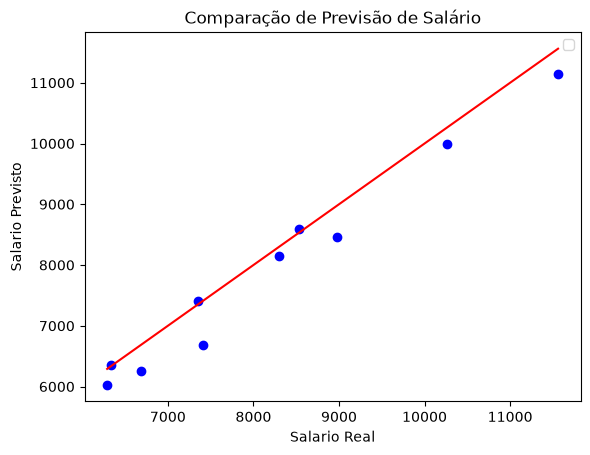

In [ ]:
#com mais parâmetros, melhor a acurácia do modelo
r2 = r2_score(y_teste, previsaoTeste) * 100

print(f"acurácia do modelo: {r2:.2f}%")

plt.scatter(y_teste, previsaoTeste, color = 'blue')

plt.plot([min(y_teste), max(y_teste)], [min(y_teste), max(y_teste)], color = 'red')

plt.title('Comparação de Previsão de Salário')
plt.xlabel('Salario Real')
plt.ylabel('Salario Previsto')

plt.show()